# Semana 10 — Exemplo estilo “fluxo de salário/transações” (PyTorch)
> Exemplo próximo do mundo real: **detectar mudança de padrão salarial** (classificação) e **prever próximo salário** (forecast).

**O que este notebook faz**
1) Gera uma série sintética que parece “depósito de salário” em ciclos (mensal/quinzenal) + ruído + eventos.
2) Cria features simples por dia (valor, dia do ciclo, flags).
3) Treina um **modelo recorrente (LSTM/GRU)** para:
   - **Classificar** se o padrão está OK vs **quebrado** (mudança de regime)
   - (Extra) **Prever** o próximo depósito (forecast)

**Por que isso é útil**
- Padrões de salário e transações são **sequenciais**.
- Heurística ajuda, mas modelos aprendem combinações e “regimes” melhor quando há muito dado.


In [1]:
# Se estiver no Colab, você pode instalar dependências assim:
# !pip install torch --index-url https://download.pytorch.org/whl/cu121
# !pip install scikit-learn pandas matplotlib

import math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cpu'

## 1) Gerando “fluxo de salário” sintético (bem realista)

Vamos simular:
- Depósito de salário em ciclos (mensal ou quinzenal)
- Valor aproximado, mas com variação (horas extras etc.)
- Ruído diário (transações aleatórias)
- Às vezes o padrão **quebra**:
  - salário some por um tempo
  - muda de frequência
  - muda muito o valor
  - vira “pinga-pinga” irregular

Vamos produzir um dataset de **muitas sequências** (cada sequência = uma janela temporal), com rótulo:
- `0` = padrão ok
- `1` = padrão quebrado / mudou regime


In [2]:
def simulate_account_series(
    days=365,
    freq="monthly",         # "monthly" or "biweekly"
    base_salary=4000,
    salary_noise=0.08,
    daily_spend_mu=120,
    daily_spend_sigma=60,
    break_prob=0.35,        # probabilidade do padrão quebrar em algum momento
):
    """Retorna DataFrame com:
    day, net_flow, salary_in, spend_out, day_in_cycle, broken (label global).
    """
    if freq == "monthly":
        period = 30
        pay_days = [0]
    elif freq == "biweekly":
        period = 14
        pay_days = [0]
    else:
        raise ValueError("freq must be monthly or biweekly")

    broken = 1 if np.random.rand() < break_prob else 0

    change_day = None
    break_type = None
    if broken:
        change_day = np.random.randint(days//3, int(days*0.85))
        break_type = np.random.choice(["missing", "freq_change", "value_shift", "irregular"])

    salary_in = np.zeros(days, dtype=float)
    spend_out = np.maximum(0.0, np.random.normal(daily_spend_mu, daily_spend_sigma, size=days))

    for d in range(days):
        if broken and change_day is not None and d >= change_day:
            if break_type == "missing":
                if d < change_day + np.random.randint(60, 121):
                    pay = 0.0
                else:
                    pay = base_salary * np.random.normal(1.0, salary_noise)
            elif break_type == "freq_change":
                period2 = 14 if freq == "monthly" else 30
                pay = base_salary * np.random.normal(1.0, salary_noise) if ((d - change_day) % period2) == 0 else 0.0
            elif break_type == "value_shift":
                new_salary = base_salary * np.random.choice([0.6, 0.75, 1.3, 1.6])
                pay = new_salary * np.random.normal(1.0, salary_noise) if (d % period) in pay_days else 0.0
            else:  # irregular
                pay = (base_salary/4) * np.random.uniform(0.6, 1.3) if np.random.rand() < 0.12 else 0.0
        else:
            pay = base_salary * np.random.normal(1.0, salary_noise) if (d % period) in pay_days else 0.0

        salary_in[d] = max(0.0, pay)

    noise = np.random.normal(0, 20, size=days)
    net_flow = salary_in - spend_out + noise
    day_in_cycle = np.array([d % period for d in range(days)], dtype=int)

    df = pd.DataFrame({
        "day": np.arange(days),
        "net_flow": net_flow,
        "salary_in": salary_in,
        "spend_out": spend_out,
        "day_in_cycle": day_in_cycle,
        "broken": broken
    })
    return df

df_one = simulate_account_series(days=180, freq=np.random.choice(["monthly","biweekly"]),
                                 base_salary=np.random.randint(2500, 8000))
df_one.head(), int(df_one["broken"].iloc[0])


(   day     net_flow    salary_in   spend_out  day_in_cycle  broken
 0    0  3068.256453  3101.980323   48.131614             0       1
 1    1  -257.429805     0.000000  248.499506             1       1
 2    2   -97.194764     0.000000  114.322740             2       1
 3    3   -59.988439     0.000000   64.270314             3       1
 4    4   -91.800955     0.000000   66.886179             4       1,
 1)

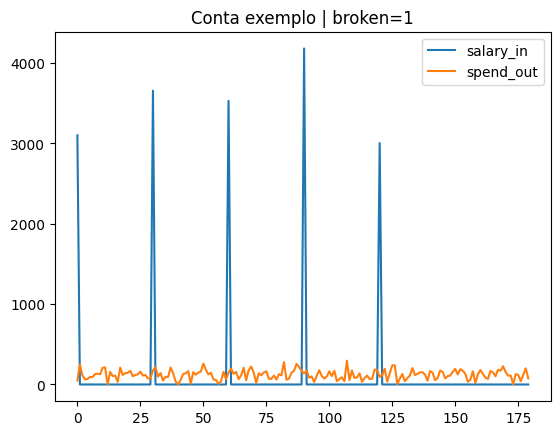

In [3]:
plt.figure()
plt.plot(df_one["salary_in"].values, label="salary_in")
plt.plot(df_one["spend_out"].values, label="spend_out")
plt.legend()
plt.title(f"Conta exemplo | broken={int(df_one['broken'].iloc[0])}")
plt.show()


## 2) Dataset de janelas (sequências)

Cada amostra é uma janela de `window_days` dias (ex: 120), com features por dia:
- `salary_in`
- `spend_out`
- `net_flow`
- `day_in_cycle` normalizado (0..1)

Label:
- `0/1` indicando se existe quebra **em algum ponto** daquela conta/janela.


In [4]:
def build_dataset(n_accounts=4000, days=180, window_days=120):
    X_list, y_list = [], []
    meta = []
    for i in range(n_accounts):
        freq = np.random.choice(["monthly","biweekly"])
        base_salary = np.random.randint(2500, 9500)
        df = simulate_account_series(days=days, freq=freq, base_salary=base_salary)

        start = np.random.randint(0, days - window_days + 1)
        win = df.iloc[start:start+window_days].copy()

        # features: (T,F)
        day_cycle = win["day_in_cycle"].values.astype(np.float32)
        day_cycle = day_cycle / max(day_cycle.max(), 1.0)

        feats = np.stack([
            win["salary_in"].values.astype(np.float32),
            win["spend_out"].values.astype(np.float32),
            win["net_flow"].values.astype(np.float32),
            day_cycle.astype(np.float32),
        ], axis=1)

        # normalização por janela (demo)
        mu = feats.mean(axis=0, keepdims=True)
        sd = feats.std(axis=0, keepdims=True) + 1e-6
        feats = (feats - mu) / sd

        label = int(win["broken"].iloc[0])
        X_list.append(feats)
        y_list.append(label)
        meta.append({"freq": freq, "base_salary": base_salary, "start": start})

    X = np.stack(X_list, axis=0)
    y = np.array(y_list, dtype=np.int64)
    return X, y, pd.DataFrame(meta)

X, y, meta = build_dataset(n_accounts=2500, days=180, window_days=120)
X.shape, float(y.mean())


((2500, 120, 4), 0.3528)

## 3) Dataset / Dataloaders

In [5]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return self.X.size(0)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

n = len(y)
idx = np.arange(n)
np.random.shuffle(idx)

train_end = int(n*0.7)
val_end = int(n*0.85)

tr_idx = idx[:train_end]
va_idx = idx[train_end:val_end]
te_idx = idx[val_end:]

train_ds = SeqDataset(X[tr_idx], y[tr_idx])
val_ds   = SeqDataset(X[va_idx], y[va_idx])
test_ds  = SeqDataset(X[te_idx], y[te_idx])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=128, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=128, shuffle=False)

len(train_ds), len(val_ds), len(test_ds)


(1750, 375, 375)

## 4) Modelo recorrente para classificação (Sequence → One)

In [6]:
class RecurrentClassifier(nn.Module):
    def __init__(self, cell="gru", input_size=4, hidden_size=64, num_layers=1, dropout=0.1):
        super().__init__()
        cell = cell.lower()
        if cell == "lstm":
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers=num_layers, batch_first=True, dropout=dropout)
        elif cell == "gru":
            self.rnn = nn.GRU(input_size, hidden_size, num_layers=num_layers, batch_first=True, dropout=dropout)
        elif cell == "rnn":
            self.rnn = nn.RNN(input_size, hidden_size, num_layers=num_layers, batch_first=True, nonlinearity="tanh", dropout=dropout)
        else:
            raise ValueError("cell must be rnn/lstm/gru")

        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size//2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size//2, 2)
        )

    def forward(self, x):
        out, _ = self.rnn(x)
        last = out[:, -1, :]
        return self.head(last)

def train_epoch(model, loader, optim, loss_fn):
    model.train()
    total = 0.0
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optim.zero_grad(set_to_none=True)
        logits = model(Xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optim.step()
        total += loss.item() * Xb.size(0)
    return total / len(loader.dataset)

@torch.no_grad()
def eval_epoch(model, loader, loss_fn):
    model.eval()
    total = 0.0
    yp, yt = [], []
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        logits = model(Xb)
        loss = loss_fn(logits, yb)
        total += loss.item() * Xb.size(0)
        pred = torch.argmax(logits, dim=1)
        yp.append(pred.cpu().numpy())
        yt.append(yb.cpu().numpy())
    yp = np.concatenate(yp)
    yt = np.concatenate(yt)
    return total / len(loader.dataset), accuracy_score(yt, yp), f1_score(yt, yp), yt, yp


## 5) Treino: RNN vs LSTM vs GRU

/Users/yandrade/PycharmProjects/ia_study/.venv/lib/python3.11/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


RNN ep01 | tr_loss 0.6732 | va_loss 0.6384 | acc 0.651 | f1 0.000
RNN ep02 | tr_loss 0.6478 | va_loss 0.6357 | acc 0.656 | f1 0.030
RNN ep04 | tr_loss 0.6319 | va_loss 0.6143 | acc 0.675 | f1 0.129
RNN ep06 | tr_loss 0.8902 | va_loss 0.7805 | acc 0.536 | f1 0.503
RNN ep08 | tr_loss 0.4538 | va_loss 0.4213 | acc 0.843 | f1 0.709
RNN ep10 | tr_loss 0.4139 | va_loss 0.2926 | acc 0.909 | f1 0.851


/Users/yandrade/PycharmProjects/ia_study/.venv/lib/python3.11/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


LSTM ep01 | tr_loss 0.6523 | va_loss 0.6439 | acc 0.651 | f1 0.000
LSTM ep02 | tr_loss 0.6485 | va_loss 0.6399 | acc 0.651 | f1 0.000
LSTM ep04 | tr_loss 0.7339 | va_loss 0.5316 | acc 0.760 | f1 0.591
LSTM ep06 | tr_loss 0.6541 | va_loss 0.6470 | acc 0.651 | f1 0.000
LSTM ep08 | tr_loss 0.6515 | va_loss 0.6460 | acc 0.651 | f1 0.000
LSTM ep10 | tr_loss 0.6480 | va_loss 0.6351 | acc 0.651 | f1 0.000


/Users/yandrade/PycharmProjects/ia_study/.venv/lib/python3.11/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


GRU ep01 | tr_loss 0.6641 | va_loss 0.6427 | acc 0.651 | f1 0.000
GRU ep02 | tr_loss 0.6480 | va_loss 0.6401 | acc 0.656 | f1 0.030
GRU ep04 | tr_loss 0.6200 | va_loss 0.5860 | acc 0.691 | f1 0.205
GRU ep06 | tr_loss 0.4238 | va_loss 0.3143 | acc 0.896 | f1 0.825
GRU ep08 | tr_loss 0.2977 | va_loss 0.2729 | acc 0.907 | f1 0.851
GRU ep10 | tr_loss 0.4494 | va_loss 0.3176 | acc 0.901 | f1 0.846


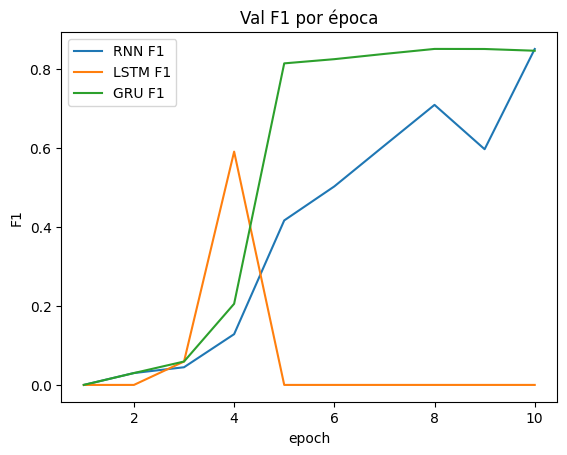

In [7]:
def fit_classifier(cell="gru", epochs=10, hidden_size=64, lr=1e-3):
    model = RecurrentClassifier(cell=cell, input_size=X.shape[-1], hidden_size=hidden_size).to(device)
    optim = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    hist = []
    for ep in range(1, epochs+1):
        tr_loss = train_epoch(model, train_loader, optim, loss_fn)
        va_loss, va_acc, va_f1, _, _ = eval_epoch(model, val_loader, loss_fn)
        hist.append((ep, tr_loss, va_loss, va_acc, va_f1))
        if ep in (1,2,4,6,8,10):
            print(f"{cell.upper()} ep{ep:02d} | tr_loss {tr_loss:.4f} | va_loss {va_loss:.4f} | acc {va_acc:.3f} | f1 {va_f1:.3f}")
    return model, pd.DataFrame(hist, columns=["epoch","train_loss","val_loss","val_acc","val_f1"])

models = {}
hists = {}
for cell in ["rnn","lstm","gru"]:
    m, h = fit_classifier(cell=cell, epochs=10, hidden_size=64, lr=1e-3)
    models[cell]=m
    hists[cell]=h

plt.figure()
for cell, h in hists.items():
    plt.plot(h["epoch"], h["val_f1"], label=f"{cell.upper()} F1")
plt.legend()
plt.title("Val F1 por época")
plt.xlabel("epoch"); plt.ylabel("F1")
plt.show()


## 6) Avaliação no teste + relatório do melhor

In [8]:
rows=[]
for cell, model in models.items():
    loss_fn = nn.CrossEntropyLoss()
    te_loss, te_acc, te_f1, y_true, y_pred = eval_epoch(model, test_loader, loss_fn)
    rows.append({"model": cell.upper(), "test_loss": te_loss, "acc": te_acc, "f1": te_f1})

df_res = pd.DataFrame(rows).sort_values("f1", ascending=False)
df_res


,model,test_loss,acc,f1
2,GRU,0.250926,0.928000,0.886076
0,RNN,0.283142,0.906667,0.840183
1,LSTM,0.615500,0.669333,0.000000


In [9]:
best_cell = df_res.iloc[0]["model"].lower()
loss_fn = nn.CrossEntropyLoss()
_, _, _, y_true, y_pred = eval_epoch(models[best_cell], test_loader, loss_fn)

print("Melhor:", best_cell.upper())
print(classification_report(y_true, y_pred, digits=3))

cm = confusion_matrix(y_true, y_pred)
cm


Melhor: GRU
              precision    recall  f1-score   support

           0      0.927     0.968     0.947       251
           1      0.929     0.847     0.886       124

    accuracy                          0.928       375
   macro avg      0.928     0.907     0.917       375
weighted avg      0.928     0.928     0.927       375



array([[243,   8],
       [ 19, 105]])

## 7) Debug rápido: exemplos de alta confiança (provável quebrado)
Vamos pegar os casos onde o modelo está mais confiante em `broken=1` e plotar a feature `salary_in` (padronizada).

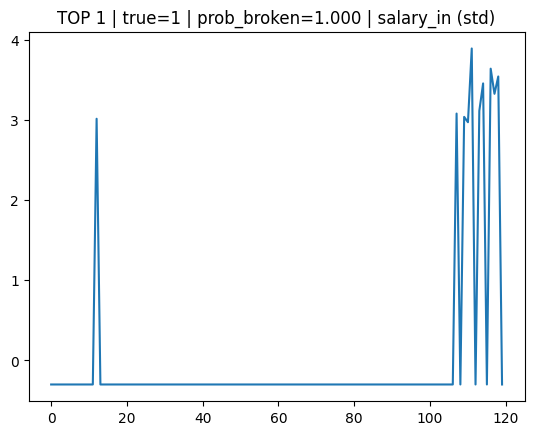

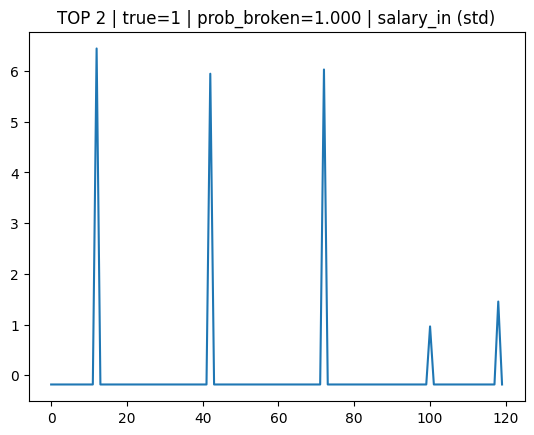

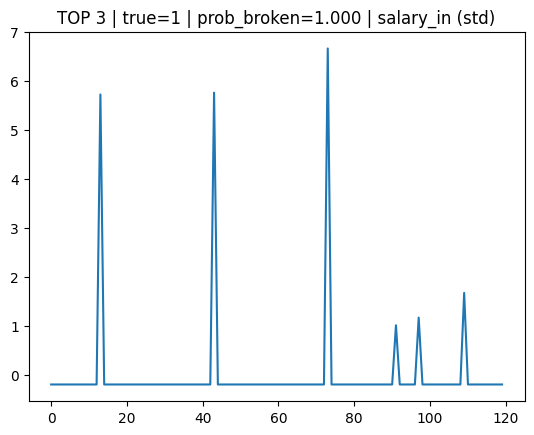

In [10]:
@torch.no_grad()
def get_probs(model, loader):
    model.eval()
    probs, trues, xs = [], [], []
    for Xb, yb in loader:
        logits = model(Xb.to(device))
        p = torch.softmax(logits, dim=1)[:,1]
        probs.append(p.cpu().numpy())
        trues.append(yb.numpy())
        xs.append(Xb.numpy())
    return np.concatenate(probs), np.concatenate(trues), np.concatenate(xs)

probs, trues, xs = get_probs(models[best_cell], test_loader)

top = np.argsort(-probs)[:3]
for i, idx in enumerate(top, 1):
    seq = xs[idx]  # (T,F)
    plt.figure()
    plt.plot(seq[:,0])  # salary_in padronizado
    plt.title(f"TOP {i} | true={trues[idx]} | prob_broken={probs[idx]:.3f} | salary_in (std)")
    plt.show()


## 8) Extra: Forecast do próximo salary_in (Sequence → One regressão)
Agora, prever o próximo dia: target = `salary_in` do dia seguinte ao final da janela.


In [11]:
def build_forecast_dataset(n_accounts=2200, days=200, window_days=120):
    X_list, y_list = [], []
    for i in range(n_accounts):
        freq = np.random.choice(["monthly","biweekly"])
        base_salary = np.random.randint(2500, 9500)
        df = simulate_account_series(days=days, freq=freq, base_salary=base_salary, break_prob=0.25)

        start = np.random.randint(0, days - window_days - 1)
        win = df.iloc[start:start+window_days].copy()
        target = float(df.iloc[start+window_days]["salary_in"])

        day_cycle = win["day_in_cycle"].values.astype(np.float32)
        day_cycle = day_cycle / max(day_cycle.max(), 1.0)

        feats = np.stack([
            win["salary_in"].values.astype(np.float32),
            win["spend_out"].values.astype(np.float32),
            win["net_flow"].values.astype(np.float32),
            day_cycle.astype(np.float32),
        ], axis=1)

        mu = feats.mean(axis=0, keepdims=True)
        sd = feats.std(axis=0, keepdims=True) + 1e-6
        feats = (feats - mu) / sd

        X_list.append(feats)
        y_list.append(target)

    return np.stack(X_list, axis=0), np.array(y_list, dtype=np.float32)

Xf, yf = build_forecast_dataset()

n = len(yf)
idx = np.arange(n); np.random.shuffle(idx)
tr = idx[:int(n*0.7)]
va = idx[int(n*0.7):int(n*0.85)]
te = idx[int(n*0.85):]

class ForecastDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return self.X.size(0)
    def __getitem__(self, i): return self.X[i], self.y[i]

tr_dl = DataLoader(ForecastDS(Xf[tr], yf[tr]), batch_size=64, shuffle=True)
va_dl = DataLoader(ForecastDS(Xf[va], yf[va]), batch_size=128, shuffle=False)
te_dl = DataLoader(ForecastDS(Xf[te], yf[te]), batch_size=128, shuffle=False)

Xf.shape, float(yf.mean()), float(yf.max())


((2200, 120, 4), 334.1170654296875, 10932.9365234375)

In [12]:
class RecurrentRegressor(nn.Module):
    def __init__(self, cell="lstm", input_size=4, hidden_size=64, dropout=0.1):
        super().__init__()
        cell = cell.lower()
        if cell == "lstm":
            self.rnn = nn.LSTM(input_size, hidden_size, batch_first=True, dropout=dropout)
        elif cell == "gru":
            self.rnn = nn.GRU(input_size, hidden_size, batch_first=True, dropout=dropout)
        else:
            self.rnn = nn.RNN(input_size, hidden_size, batch_first=True, nonlinearity="tanh", dropout=dropout)

        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size//2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size//2, 1)
        )

    def forward(self, x):
        out, _ = self.rnn(x)
        last = out[:, -1, :]
        return self.head(last).squeeze(-1)

def fit_regressor(cell="lstm", epochs=8, lr=1e-3):
    model = RecurrentRegressor(cell=cell, input_size=4, hidden_size=64).to(device)
    optim = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for ep in range(1, epochs+1):
        model.train()
        tr_loss = 0.0
        for Xb, yb in tr_dl:
            Xb, yb = Xb.to(device), yb.to(device)
            optim.zero_grad(set_to_none=True)
            pred = model(Xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optim.step()
            tr_loss += loss.item() * Xb.size(0)
        tr_loss /= len(tr_dl.dataset)

        model.eval()
        va_loss = 0.0
        preds=[]; trues=[]
        with torch.no_grad():
            for Xb, yb in va_dl:
                Xb, yb = Xb.to(device), yb.to(device)
                pred = model(Xb)
                loss = loss_fn(pred, yb)
                va_loss += loss.item() * Xb.size(0)
                preds.append(pred.cpu().numpy())
                trues.append(yb.cpu().numpy())
        va_loss /= len(va_dl.dataset)

        if ep in (1,2,4,6,8):
            preds_np = np.concatenate(preds)
            trues_np = np.concatenate(trues)
            rmse = math.sqrt(((preds_np - trues_np)**2).mean())
            print(f"{cell.upper()} ep{ep:02d} | tr_mse {tr_loss:.1f} | va_mse {va_loss:.1f} | va_rmse {rmse:.1f}")

    return model

reg = fit_regressor("lstm", epochs=8, lr=1e-3)

# Test
reg.eval()
with torch.no_grad():
    preds=[]; trues=[]
    for Xb, yb in te_dl:
        pred = reg(Xb.to(device))
        preds.append(pred.cpu().numpy())
        trues.append(yb.numpy())

preds = np.concatenate(preds)
trues = np.concatenate(trues)

rmse = math.sqrt(((preds - trues)**2).mean())
mae = float(np.mean(np.abs(preds - trues)))
rmse, mae


/Users/yandrade/PycharmProjects/ia_study/.venv/lib/python3.11/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


LSTM ep01 | tr_mse 2277203.3 | va_mse 2110544.1 | va_rmse 1452.8
LSTM ep02 | tr_mse 2275984.4 | va_mse 2107998.8 | va_rmse 1451.9
LSTM ep04 | tr_mse 2269261.7 | va_mse 2100828.5 | va_rmse 1449.4
LSTM ep06 | tr_mse 2261068.2 | va_mse 2091906.6 | va_rmse 1446.3
LSTM ep08 | tr_mse 2251996.1 | va_mse 2082903.3 | va_rmse 1443.2


(1298.28901828522, 318.36102294921875)

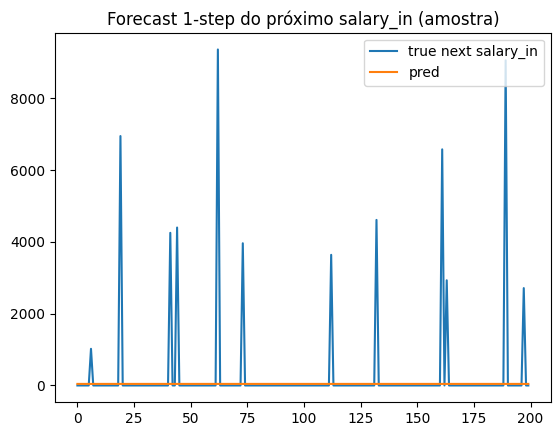

In [13]:
k = 200
plt.figure()
plt.plot(trues[:k], label="true next salary_in")
plt.plot(preds[:k], label="pred")
plt.legend()
plt.title("Forecast 1-step do próximo salary_in (amostra)")
plt.show()


## 9) Como plugar no seu dado real (sem expor nada)

Se você tiver algo tipo:
- `account_id`, `date`, `salary_in`, `spend_out` (ou debits), `net_flow`

Você faz:
1) construir janelas por `account_id` e tempo
2) gerar labels (ex.: '60 dias sem salário após padrão' → `broken=1`)
3) treinar e avaliar (split temporal)

**Checklist de produção**
- split temporal (evita leak)
- normalização consistente
- baseline tabular (rolling stats + logistic/xgb)
- classe rara: F1/PR-AUC
- monitoramento de drift
